In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import chi2_contingency
import queue
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

In [2]:
def preprocess_data(df):
    df.drop(columns=["Unnamed: 0.1", "Unnamed: 0", "sessionId", "time", "th1", "th1_value", 'th2', 'th2_value', 'th3', 'th3_value', 'wudate', 'lon', 'lat'], inplace=True)
    df["fusion_model_prediction"] = df["fusion_model_prediction"].replace("NO PREDICTION (0.0000)", None)
    df["Call_Presence"] = df["fusion_model_prediction"].notnull().astype(int)

    print("Aviary Data:")
    print(df.head())

    return df

In [3]:
# Load and preprocess the data
selected_1_avriary_path = "metadata_aviaries/fl_zoo_eindhoven_20250308_meta.xlsx"
selected_2_avriary_path = "metadata_aviaries/fl_zoo_eindhoven_20250426_meta.xlsx"

if not os.path.exists("processed_data"):
    os.makedirs("processed_data")
    df_1 = pd.read_excel(selected_1_avriary_path)
    df_2 = pd.read_excel(selected_2_avriary_path)

    df_1 = preprocess_data(df_1)
    df_2 = preprocess_data(df_2)

    
    df_1.to_pickle("processed_data/aviary_1_data.pkl")
    df_2.to_pickle("processed_data/aviary_2_data.pkl")
else:
    df_1 = pd.read_pickle("processed_data/aviary_1_data.pkl")
    df_2 = pd.read_pickle("processed_data/aviary_2_data.pkl")


In [7]:
def clean_prediction(df):
    df["birdnet_prediction"] = df["birdnet_prediction"].replace("NO PREDICTION (0.0000)", None)
    df["Final prediction"] = None
    
    for idx, row in df.iterrows():

        subset = str(row["birdnet_prediction"]).split(" ")
        try:
            if subset[0] == "nan":
                row["Final prediction"] = None
                continue

            pred_score = subset[-1]
            if float(pred_score[1:-1]) < 0.15:
                row["Final prediction"] = None
                continue
            tmp_pred = ""
            for string in subset[:-1]:
                tmp_pred += string + " "

            df.loc[idx, "Final prediction"] = tmp_pred

        except Exception as error:
            print(f"Error processing row {idx}: {error}")
            print(subset)
    
    return df

df_1 = clean_prediction(df_1)
df_2 = clean_prediction(df_2)


In [5]:
counts = df_1["MIT_AST_label"].value_counts()
for e in counts.index:
    print(f"{e}: {counts[e]}")

Animal: 15776
Fowl: 11188
speech_removed: 8980
Honk: 7983
Quack: 6985
Bird: 5132
Vehicle: 2299
Duck: 2156
Crow: 1954
Oink: 1892
Frog: 1850
Throat clearing: 696
Roar: 604
Raindrop: 514
Squawk: 493
Music: 467
Chicken, rooster: 423
Owl: 420
Caw: 409
Engine: 383
Goose: 373
Bow-wow: 269
Vehicle horn, car horn, honking: 208
Bleat: 196
Hoot: 189
Howl: 188
Water: 167
Chirp, tweet: 155
Liquid: 145
Sheep: 121
Squeak: 119
Sawing: 110
Roaring cats (lions, tigers): 101
Dog: 94
Rub: 86
Bird vocalization, bird call, bird song: 83
Cattle, bovinae: 80
Train: 78
Cluck: 77
Rain: 68
Crowing, cock-a-doodle-doo: 64
Sound effect: 59
Domestic animals, pets: 56
Rain on surface: 46
Livestock, farm animals, working animals: 43
Rattle: 43
Whale vocalization: 41
Squeal: 29
Whistling: 28
Canidae, dogs, wolves: 27
Snort: 26
Bird flight, flapping wings: 24
Wood: 22
Moo: 21
Gurgling: 19
Clip-clop: 16
Gasp: 16
Cat: 15
Pant: 14
Snicker: 13
Turkey: 13
Stream: 12
Mechanisms: 12
Crowd: 10
Sneeze: 10
Boiling: 10
Thunderstor

In [45]:
for r in df_1['MIT_AST_label'].unique():
    print(r)

speech_removed
Whack, thwack
Fowl
Animal
Oink
Crowd
Honk
Rub
Sawing
Squeal
Vehicle
Chicken, rooster
Sound effect
Quack
Frog
Caw
Bird
Duck
Squawk
Crow
Music
Dog
Bleat
Bow-wow
Throat clearing
Crowing, cock-a-doodle-doo
Goose
Croak
Roar
Livestock, farm animals, working animals
Roaring cats (lions, tigers)
Wood
Snicker
Battle cry
Owl
Raindrop
Squeak
Liquid
Clip-clop
Sheep
Scrape
Snort
Domestic animals, pets
Whistling
Engine
Canidae, dogs, wolves
Howl
Water
Vehicle horn, car horn, honking
Pant
Crack
Rain
Foghorn
Gurgling
Rain on surface
Car
Train
Hoot
Heart sounds, heartbeat
Hum
Whale vocalization
Sneeze
Chink, clink
Moo
Cat
Gobble
Cattle, bovinae
Drip
Turkey
Boiling
Rattle
Stream
Clapping
Burping, eructation
Buzzer
Pour
Bird flight, flapping wings
Cluck
Chirp, tweet
Bird vocalization, bird call, bird song
Gargling
Slosh
Mechanisms
Neigh, whinny
Horse
Thunder
Toilet flush
Meow
Typing
Gasp
Medium engine (mid frequency)
Tick-tock
Typewriter
Applause
Clang
Toothbrush
Rumble
Siren
Throbbing
Whi

In [ ]:
MIT_classes_of_interest = ["Crowd", "Civil defense siren", "Railroad car, train wagon", "Vehicle", "Motorcycle", "Thunderstorm", "Air horn, truck horn", 
                           "Grunt", "Engine starting", "Siren", "Medium engine (mid frequency)", "Thunder", "Train", "Car", "Vehicle horn, car horn, honking",
                           "Roaring cats (lions, tigers)", "Roar", "Dog"]
previous_event = None
call_dict = {}

for idx, row in df_1.iterrows():
    prediction = str(row["Final prediction"])
    current_event = row["MIT_AST_label"]
    
    if prediction != "None" and previous_event in MIT_classes_of_interest:
        key = prediction + "-" + str(previous_event) 
        if key not in call_dict:
            call_dict[key] = 0
        
        call_dict[key] += 1
    
    previous_event = current_event

print(call_dict)

{'Phoenicopterus roseus Greater Flamingo -Vehicle': 475, 'Phoenicopterus roseus Greater Flamingo -Dog': 47, 'Phoenicopterus roseus Greater Flamingo -Crowd': 8, 'Phoenicopterus roseus Greater Flamingo -Roar': 82, 'Phoenicopterus roseus Greater Flamingo -Roaring cats (lions, tigers)': 11, 'Columba livia Rock Pigeon -Roaring cats (lions, tigers)': 14, 'Corvus monedula Eurasian Jackdaw -Roaring cats (lions, tigers)': 12, 'Geronticus eremita Northern Bald Ibis -Roaring cats (lions, tigers)': 3, 'Passer domesticus House Sparrow -Vehicle': 53, 'Egretta garzetta Little Egret -Vehicle': 10, 'Columba livia Rock Pigeon -Roar': 145, 'Columba palumbus Common Wood Pigeon -Roar': 80, 'Pica pica Eurasian Magpie -Vehicle': 61, 'Pica pica Eurasian Magpie -Dog': 7, 'Ciconia ciconia White Stork -Vehicle': 531, 'Gallinula chloropus Eurasian Moorhen -Vehicle': 78, 'Gallinula chloropus Eurasian Moorhen -Roar': 37, 'Geronticus eremita Northern Bald Ibis -Roar': 47, 'Egretta garzetta Little Egret -Roar': 19, '

In [ ]:
reaction_df = pd.DataFrame([
    {'species': k.rsplit('-', 1)[0], 'event': k.rsplit('-', 1)[1], 'count': v} 
    for k, v in call_dict.items()
])

species_totals = reaction_df.groupby('species')['count'].sum().sort_values(ascending=False)
print("Most reactive species:")
print(species_totals.head(10))

event_totals = reaction_df.groupby('event')['count'].sum().sort_values(ascending=False)
print("\nMost reactive events:")
print(event_totals.head(10))

Most reactive species:
species
Phoenicopterus roseus Greater Flamingo     734
Ciconia ciconia White Stork                594
Columba palumbus Common Wood Pigeon        198
Columba livia Rock Pigeon                  173
Gallinula chloropus Eurasian Moorhen       128
Pica pica Eurasian Magpie                   87
Passer domesticus House Sparrow             83
Geronticus eremita Northern Bald Ibis       70
Corvus monedula Eurasian Jackdaw            65
Egretta garzetta Little Egret               36
Name: count, dtype: int64

Most reactive events:
event
Vehicle                            1398
Roar                                499
Vehicle horn, car horn, honking     126
Roaring cats (lions, tigers)         76
Dog                                  61
Train                                36
Crowd                                 8
Car                                   8
Thunder                               5
Siren                                 5
Name: count, dtype: int64


In [ ]:
# Make pivot table comparing species and events rate 
reaction_df = reaction_df.drop(reaction_df[reaction_df['count'] < 5].index) 

pivot_table = reaction_df.pivot_table(index='species', columns='event', values='count', fill_value=0)
display(pivot_table)

Pivot table of species vs events:


event,Crowd,Dog,Roar,"Roaring cats (lions, tigers)",Train,Vehicle,"Vehicle horn, car horn, honking"
species,,,,,,,
Branta canadensis Canada Goose,0.0,0.0,0.0,0.0,0.0,12.0,0.0
Ciconia ciconia White Stork,0.0,0.0,40.0,14.0,0.0,531.0,5.0
Columba livia Rock Pigeon,0.0,0.0,145.0,14.0,0.0,10.0,0.0
Columba palumbus Common Wood Pigeon,0.0,0.0,80.0,0.0,10.0,104.0,0.0
Corvus corone Carrion Crow,0.0,0.0,0.0,0.0,0.0,18.0,0.0
Corvus monedula Eurasian Jackdaw,0.0,0.0,16.0,12.0,0.0,30.0,0.0
Egretta garzetta Little Egret,0.0,0.0,19.0,0.0,0.0,10.0,0.0
Gallinula chloropus Eurasian Moorhen,0.0,0.0,37.0,0.0,0.0,78.0,10.0
Geronticus eremita Northern Bald Ibis,0.0,0.0,47.0,0.0,0.0,14.0,0.0


## Do something similar but looking at bird vocalisation preciding a vocalisation

In [ ]:
vocalisation_reaction = {}
previous_vocalisation = None

for idx, row in df_1.iterrows():
    current_prediction = str(row["Final prediction"])
    
    if current_prediction != "None":
        key = current_prediction + "- " + str(previous_vocalisation)
        
        if key not in vocalisation_reaction:
            vocalisation_reaction[key] = 0
        
        vocalisation_reaction[key] += 1
    
    previous_vocalisation = current_prediction

print(vocalisation_reaction)


{'Phoenicopterus roseus Greater Flamingo -None': 7376, 'Phoenicopterus roseus Greater Flamingo -Phoenicopterus roseus Greater Flamingo ': 25845, 'Pica pica Eurasian Magpie -None': 869, 'Phoenicopterus roseus Greater Flamingo -Pica pica Eurasian Magpie ': 631, 'Branta canadensis Canada Goose -None': 152, 'Phoenicopterus roseus Greater Flamingo -Branta canadensis Canada Goose ': 182, 'Gallinula chloropus Eurasian Moorhen -None': 653, 'Gallinula chloropus Eurasian Moorhen -Phoenicopterus roseus Greater Flamingo ': 460, 'Phoenicopterus roseus Greater Flamingo -Gallinula chloropus Eurasian Moorhen ': 494, 'Corvus monedula Eurasian Jackdaw -Phoenicopterus roseus Greater Flamingo ': 330, 'Ciconia ciconia White Stork -None': 877, 'Phoenicopterus roseus Greater Flamingo -Ciconia ciconia White Stork ': 569, 'Ciconia ciconia White Stork -Phoenicopterus roseus Greater Flamingo ': 541, 'Passer domesticus House Sparrow -None': 678, 'Phoenicopterus roseus Greater Flamingo -Passer domesticus House Spa

In [57]:
# Make pivot table comparing species and events rate 
vocalisation_reaction_df = pd.DataFrame([
    {'species': k.rsplit('-', 1)[0], 'vocalisation': k.rsplit('-', 1)[1], 'count': v} 
    for k, v in vocalisation_reaction.items()
])
vocalisation_reaction_df = vocalisation_reaction_df.drop(vocalisation_reaction_df[vocalisation_reaction_df['count'] < 5].index) 

pivot_table = vocalisation_reaction_df.pivot_table(index='species', columns='vocalisation', values='count', fill_value=0)
display(pivot_table)

vocalisation,Branta canadensis Canada Goose,Ciconia ciconia White Stork,Ciconia nigra Black Stork,Columba livia Rock Pigeon,Columba palumbus Common Wood Pigeon,Corvus corone Carrion Crow,Corvus monedula Eurasian Jackdaw,Egretta garzetta Little Egret,Fulica atra Eurasian Coot,Gallinula chloropus Eurasian Moorhen,Geronticus eremita Northern Bald Ibis,Mareca sibilatrix Chiloe Wigeon,None,Passer domesticus House Sparrow,Phoenicopterus roseus Greater Flamingo,Pica pica Eurasian Magpie,Streptopelia decaocto Eurasian Collared Dove
species,,,,,,,,,,,,,,,,,
Branta canadensis Canada Goose,38.0,7.0,0.0,0.0,5.0,0.0,7.0,0.0,0.0,8.0,0.0,0.0,152.0,13.0,176.0,9.0,0.0
Ciconia ciconia White Stork,13.0,1487.0,0.0,8.0,15.0,0.0,75.0,11.0,0.0,58.0,0.0,0.0,877.0,82.0,541.0,107.0,0.0
Ciconia nigra Black Stork,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,59.0,0.0,19.0,5.0,0.0
Columba livia Rock Pigeon,0.0,12.0,0.0,240.0,40.0,0.0,13.0,7.0,0.0,18.0,23.0,0.0,94.0,25.0,43.0,15.0,0.0
Columba palumbus Common Wood Pigeon,0.0,7.0,0.0,55.0,132.0,7.0,9.0,7.0,0.0,28.0,27.0,9.0,247.0,8.0,91.0,14.0,8.0
Corvus corone Carrion Crow,0.0,6.0,0.0,0.0,6.0,41.0,17.0,0.0,0.0,15.0,0.0,0.0,100.0,12.0,53.0,20.0,0.0
Corvus monedula Eurasian Jackdaw,0.0,72.0,0.0,12.0,9.0,15.0,580.0,10.0,0.0,55.0,7.0,0.0,435.0,124.0,330.0,170.0,7.0
Egretta garzetta Little Egret,0.0,19.0,0.0,9.0,5.0,0.0,13.0,66.0,0.0,28.0,6.0,0.0,256.0,17.0,288.0,28.0,0.0
Fulica atra Eurasian Coot,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,30.0,0.0,22.0,6.0,0.0


## Looking at Native bird to aviary

In [ ]:
display(df_1['Final prediction'].value_counts())
display(df_2['Final prediction'].value_counts())


Final prediction
Phoenicopterus roseus Greater Flamingo           36090
Pica pica Eurasian Magpie                         3376
Ciconia ciconia White Stork                       3260
Passer domesticus House Sparrow                   2630
Corvus monedula Eurasian Jackdaw                  1816
Gallinula chloropus Eurasian Moorhen              1728
Egretta garzetta Little Egret                      699
Columba palumbus Common Wood Pigeon                630
Columba livia Rock Pigeon                          524
Branta canadensis Canada Goose                     417
Geronticus eremita Northern Bald Ibis              360
Corvus corone Carrion Crow                         261
Streptopelia decaocto Eurasian Collared Dove       180
Ciconia nigra Black Stork                          142
Mareca sibilatrix Chiloe Wigeon                    109
Fulica atra Eurasian Coot                           76
Phylloscopus collybita Common Chiffchaff            16
Fringilla coelebs Eurasian Chaffinch            

Final prediction
Phoenicopterus roseus Greater Flamingo           49448
Passer domesticus House Sparrow                   8438
Egretta garzetta Little Egret                     1987
Ciconia ciconia White Stork                       1367
Corvus monedula Eurasian Jackdaw                  1217
Geronticus eremita Northern Bald Ibis             1095
Gallinula chloropus Eurasian Moorhen              1061
Columba livia Rock Pigeon                          442
Branta canadensis Canada Goose                     373
Streptopelia decaocto Eurasian Collared Dove       357
Pica pica Eurasian Magpie                          347
Columba palumbus Common Wood Pigeon                308
Corvus corone Carrion Crow                         104
Mareca sibilatrix Chiloe Wigeon                    101
Milvus migrans Black Kite                           54
Fulica atra Eurasian Coot                           19
Fringilla coelebs Eurasian Chaffinch                17
Ciconia nigra Black Stork                       

In [ ]:
def classify_natives(df):
    natives = ["Black kite", "Black stork", "Chiloe wigeon", "Goliath heron", "Greater flamingo", "Little egret", "Northern bald ibis", "Pink-backed pelican", "Scarlet ibis", "Straw-necked ibis"]
    for idx, row in df.iterrows():

        for native in natives:
            if str(row["Final prediction"]).contains(native):
                df.loc[idx, "Native"] = True
                break
            
        else:
            df.loc[idx, "Native"] = False
    
    df["Native"] = df["Final prediction"].isin(natives)



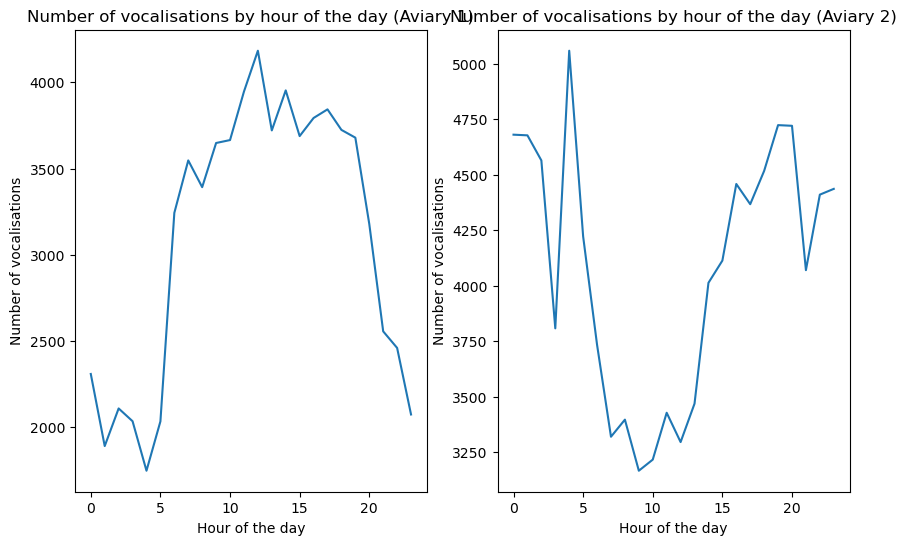

In [27]:
# See number of vocalisation based on time of day
df_1['time'] = pd.to_datetime(df_1['datetime'])
df_1['hour'] = df_1['time'].dt.hour

df_2['time'] = pd.to_datetime(df_2['datetime'])
df_2['hour'] = df_2['time'].dt.hour

plt.subplots(figsize=(10, 6))
plt.subplot(1, 2, 1)
df_1['hour'].value_counts().sort_index().plot(kind='line')
plt.title("Number of vocalisations by hour of the day (Aviary 1)")
plt.xlabel("Hour of the day")
plt.ylabel("Number of vocalisations")

plt.subplot(1, 2, 2)
df_2['hour'].value_counts().sort_index().plot(kind='line')
plt.title("Number of vocalisations by hour of the day (Aviary 2)")
plt.xlabel("Hour of the day")
plt.ylabel("Number of vocalisations")   
plt.show()

In [24]:
# Average rain precipitation per dataset
print(df_1["precipRate"].sum())
print(df_2["precipRate"].sum())

257.40000000000003
0


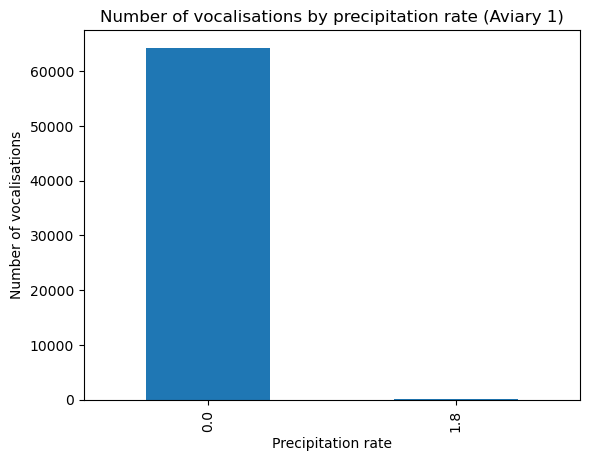

In [29]:
# Compare precipitation rate to the number of vocalisations in data set 1, because set 2 does not have any rain
df_1.groupby("precipRate")["Call_Presence"].sum().plot(kind="bar")
plt.title("Number of vocalisations by precipitation rate (Aviary 1)")
plt.xlabel("Precipitation rate")
plt.ylabel("Number of vocalisations")
plt.show()

In [4]:
# See effect of rain on vocalisations
# precipRate we dont know the measure, not explained in the README
"""
rainy_days = df[df["precipRate"] > 0.25] 
rainy_days_calls = rainy_days["fusion_model_prediction"].notnull().sum()

non_rainy_days = df[df["precipRate"] <= 0.25] 
non_rainy_days_calls = non_rainy_days["fusion_model_prediction"].notnull().sum()

print(f'Rainy days vocalisations: {rainy_days_calls/len(rainy_days)*100:.2f}%')
print(f'Non-rainy days vocalisations: {non_rainy_days_calls/len(non_rainy_days)*100:.2f}%')


df['rain'] = (df['precipRate'] > 0.25).astype(int)
contingency_table = pd.crosstab(df['rain'], df['Call_Presence'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(contingency_table)
print(f"Chi-squared: {chi2:.4f}, p-value: {p_value:.4f}") # Not sure this test is correct
"""

'\nrainy_days = df[df["precipRate"] > 0.25] \nrainy_days_calls = rainy_days["fusion_model_prediction"].notnull().sum()\n\nnon_rainy_days = df[df["precipRate"] <= 0.25] \nnon_rainy_days_calls = non_rainy_days["fusion_model_prediction"].notnull().sum()\n\nprint(f\'Rainy days vocalisations: {rainy_days_calls/len(rainy_days)*100:.2f}%\')\nprint(f\'Non-rainy days vocalisations: {non_rainy_days_calls/len(non_rainy_days)*100:.2f}%\')\n\n\ndf[\'rain\'] = (df[\'precipRate\'] > 0.25).astype(int)\ncontingency_table = pd.crosstab(df[\'rain\'], df[\'Call_Presence\'])\nchi2, p_value, dof, expected = chi2_contingency(contingency_table)\n\nprint(contingency_table)\nprint(f"Chi-squared: {chi2:.4f}, p-value: {p_value:.4f}") # Not sure this test is correct\n'

In [5]:
# Look at the impact of temperature on vocalisations
"""
print(f"Maximum temperature: {df['tempAve'].max()}, Minimum temperature: {df['tempAve'].min()}\n")

bins = [df['tempAve'].min(), 20, df['tempAve'].max()]
bins = [i for i in range(int(df['tempAve'].min()), int(df['tempAve'].max()) + 1, 5)]

df['temp_category'] = pd.cut(df['tempAve'], bins=bins)
counts = df.groupby('temp_category')['Call_Presence'].count()/len(df)

print(counts)
"""

'\nprint(f"Maximum temperature: {df[\'tempAve\'].max()}, Minimum temperature: {df[\'tempAve\'].min()}\n")\n\nbins = [df[\'tempAve\'].min(), 20, df[\'tempAve\'].max()]\nbins = [i for i in range(int(df[\'tempAve\'].min()), int(df[\'tempAve\'].max()) + 1, 5)]\n\ndf[\'temp_category\'] = pd.cut(df[\'tempAve\'], bins=bins)\ncounts = df.groupby(\'temp_category\')[\'Call_Presence\'].count()/len(df)\n\nprint(counts)\n'